In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("credit_risk_dataset.csv")

In [6]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [9]:
df.dtypes

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


In [10]:
df.duplicated().sum()

np.int64(165)

In [11]:
df.drop_duplicates()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [12]:
df.duplicated().sum()

np.int64(165)

In [13]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
32576,False
32577,False
32578,False
32579,False


In [14]:
df = df.drop_duplicates()

In [15]:
print(df.duplicated().sum())

0


In [16]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,887
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3095
loan_status,0
loan_percent_income,0


In [17]:
df.dtypes

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


In [18]:
df["person_emp_length"].fillna(df["person_emp_length"].mean(),inplace=True)
df["loan_int_rate"].fillna(df["loan_int_rate"].mean(),inplace=True)

/tmp/ipykernel_2175/3983919217.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["person_emp_length"].fillna(df["person_emp_length"].mean(),inplace=True)
/tmp/ipykernel_2175/3983919217.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

In [19]:

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    if col == 'loan_status':   # Skip target column
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

person_age: 1491 outliers
person_income: 1478 outliers
person_emp_length: 852 outliers
loan_amnt: 1679 outliers
loan_int_rate: 70 outliers
loan_percent_income: 650 outliers
cb_person_cred_hist_length: 1139 outliers


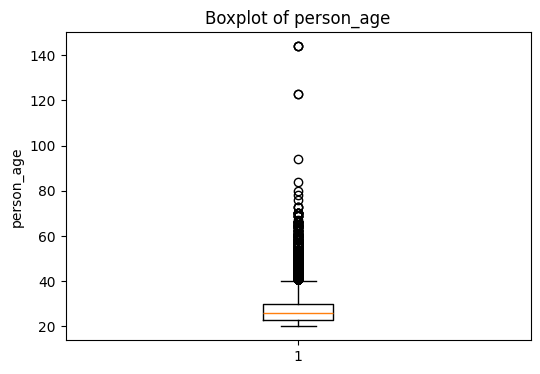

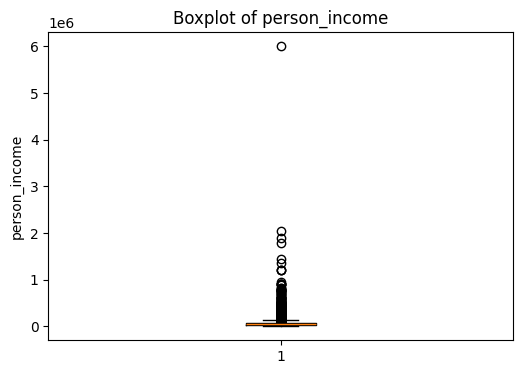

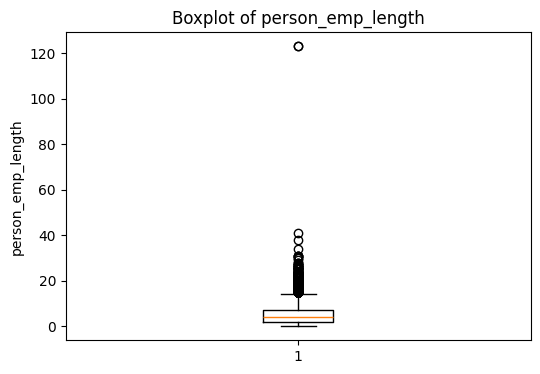

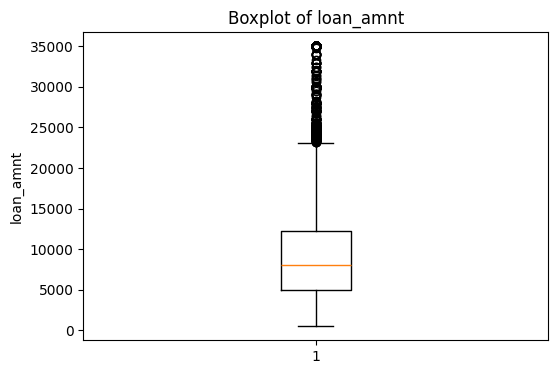

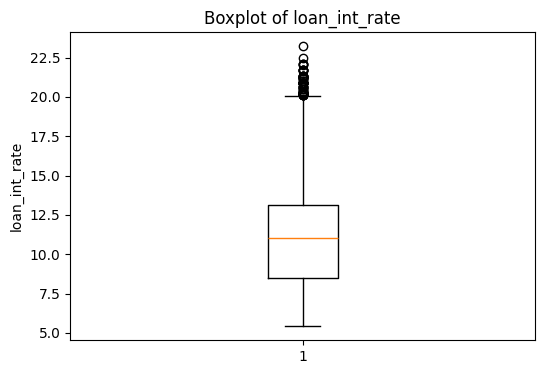

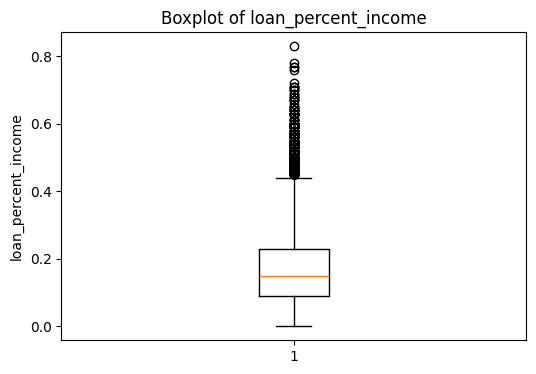

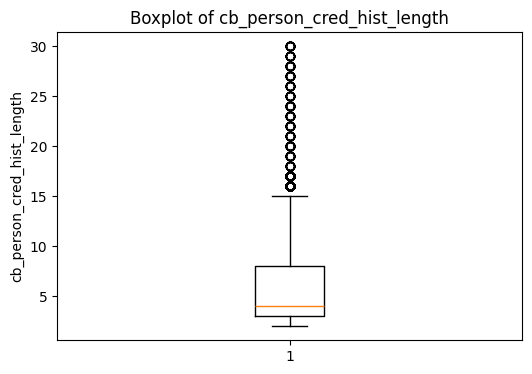

In [20]:

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('loan_status')

for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [21]:
import pandas as pd

# Numerical columns (excluding target)
num_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

# Create a copy
df_clean = df.copy()

# Remove outliers column by column
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]

print("Original Shape:", df.shape)
print("New Shape:", df_clean.shape)

Original Shape: (32416, 12)
New Shape: (26006, 12)


In [22]:
print("Rows removed:", len(df) - len(df_clean))
print("Rows remaining:", len(df_clean))

Rows removed: 6410
Rows remaining: 26006


In [23]:
df.dtypes

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


In [24]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


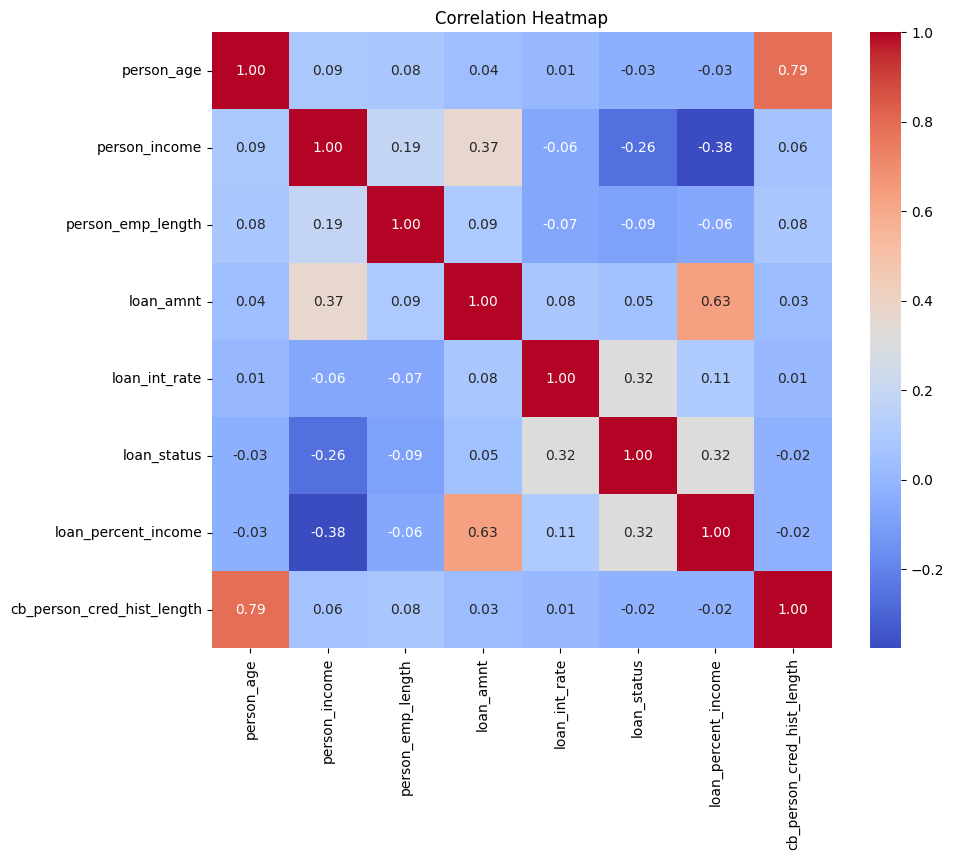

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df_clean.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()
#

In [26]:
# Drop in-place (modifies original DataFrame)
df.drop('person_age', axis=1, inplace=True)

In [27]:
df_fe = df_clean.copy()

In [28]:
df_fe['income_loan_ratio'] = (
    df_fe['person_income'] /
    df_fe['loan_amnt']
)

In [29]:
df_fe

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_loan_ratio
1,21,9600,OWN,5.00000,EDUCATION,B,1000,11.140000,0,0.10,N,2,9.600000
5,21,9900,OWN,2.00000,VENTURE,A,2500,7.140000,1,0.25,N,2,3.960000
9,21,10000,OWN,6.00000,VENTURE,D,1600,14.740000,1,0.16,N,3,6.250000
19,24,10800,MORTGAGE,8.00000,EDUCATION,B,1750,10.990000,1,0.16,N,2,6.171429
23,24,10980,OWN,0.00000,PERSONAL,A,1500,7.290000,0,0.14,N,3,7.320000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32256,38,59475,MORTGAGE,10.00000,MEDICAL,D,18125,14.840000,1,0.26,Y,13,3.281379
32258,38,67870,MORTGAGE,6.00000,MEDICAL,B,5000,11.017265,0,0.07,N,13,13.574000
32269,37,21600,RENT,4.00000,MEDICAL,D,3800,11.017265,1,0.18,N,11,5.684211
32285,38,12000,OWN,4.79051,EDUCATION,A,4800,7.290000,1,0.40,N,12,2.500000


In [30]:
df_fe['credit_history_ratio'] = (
    df_fe['cb_person_cred_hist_length'] /
    df_fe['person_age']
)

In [31]:
df_fe['employment_ratio'] = (
    df_fe['person_emp_length'] /
    df_fe['person_age']
)

In [32]:
df_fe['interest_amount'] = (
    df_fe['loan_amnt'] *
    df_fe['loan_int_rate'] / 100
)

In [33]:
import numpy as np

df_fe['log_income'] = np.log1p(df_fe['person_income'])

In [34]:
df_fe['log_loan_amount'] = np.log1p(df_fe['loan_amnt'])

In [35]:
df_fe['stable_job'] = (
    df_fe['person_emp_length'] >= 5
).astype(int)

In [36]:
df_fe['high_debt'] = (
    df_fe['loan_percent_income'] >= 0.40
).astype(int)

In [37]:
df_fe['default_history'] = (
    df_fe['cb_person_default_on_file'] == 'Y'
).astype(int)

In [38]:
df_fe['age_group'] = pd.cut(
    df_fe['person_age'],
    bins=[18,25,35,45,60,100],
    labels=[
        '18-25',
        '26-35',
        '36-45',
        '46-60',
        '60+'
    ]
)

In [39]:
df_fe['income_category'] = pd.qcut(
    df_fe['person_income'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

In [40]:
df_fe.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,credit_history_ratio,employment_ratio,interest_amount,log_income,log_loan_amount,stable_job,high_debt,default_history,age_group,income_category
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,...,0.095238,0.238095,111.400,9.169623,6.908755,1,0,0,18-25,Low
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,...,0.095238,0.095238,178.500,9.200391,7.824446,0,0,0,18-25,Low
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,...,0.142857,0.285714,235.840,9.210440,7.378384,1,0,0,18-25,Low
19,24,10800,MORTGAGE,8.0,EDUCATION,B,1750,10.99,1,0.16,...,0.083333,0.333333,192.325,9.287394,7.467942,1,0,0,18-25,Low
23,24,10980,OWN,0.0,PERSONAL,A,1500,7.29,0,0.14,...,0.125000,0.000000,109.350,9.303922,7.313887,0,0,0,18-25,Low


In [41]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26006 entries, 1 to 32293
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  26006 non-null  int64   
 1   person_income               26006 non-null  int64   
 2   person_home_ownership       26006 non-null  object  
 3   person_emp_length           26006 non-null  float64 
 4   loan_intent                 26006 non-null  object  
 5   loan_grade                  26006 non-null  object  
 6   loan_amnt                   26006 non-null  int64   
 7   loan_int_rate               26006 non-null  float64 
 8   loan_status                 26006 non-null  int64   
 9   loan_percent_income         26006 non-null  float64 
 10  cb_person_default_on_file   26006 non-null  object  
 11  cb_person_cred_hist_length  26006 non-null  int64   
 12  income_loan_ratio           26006 non-null  float64 
 13  credit_history_ratio 

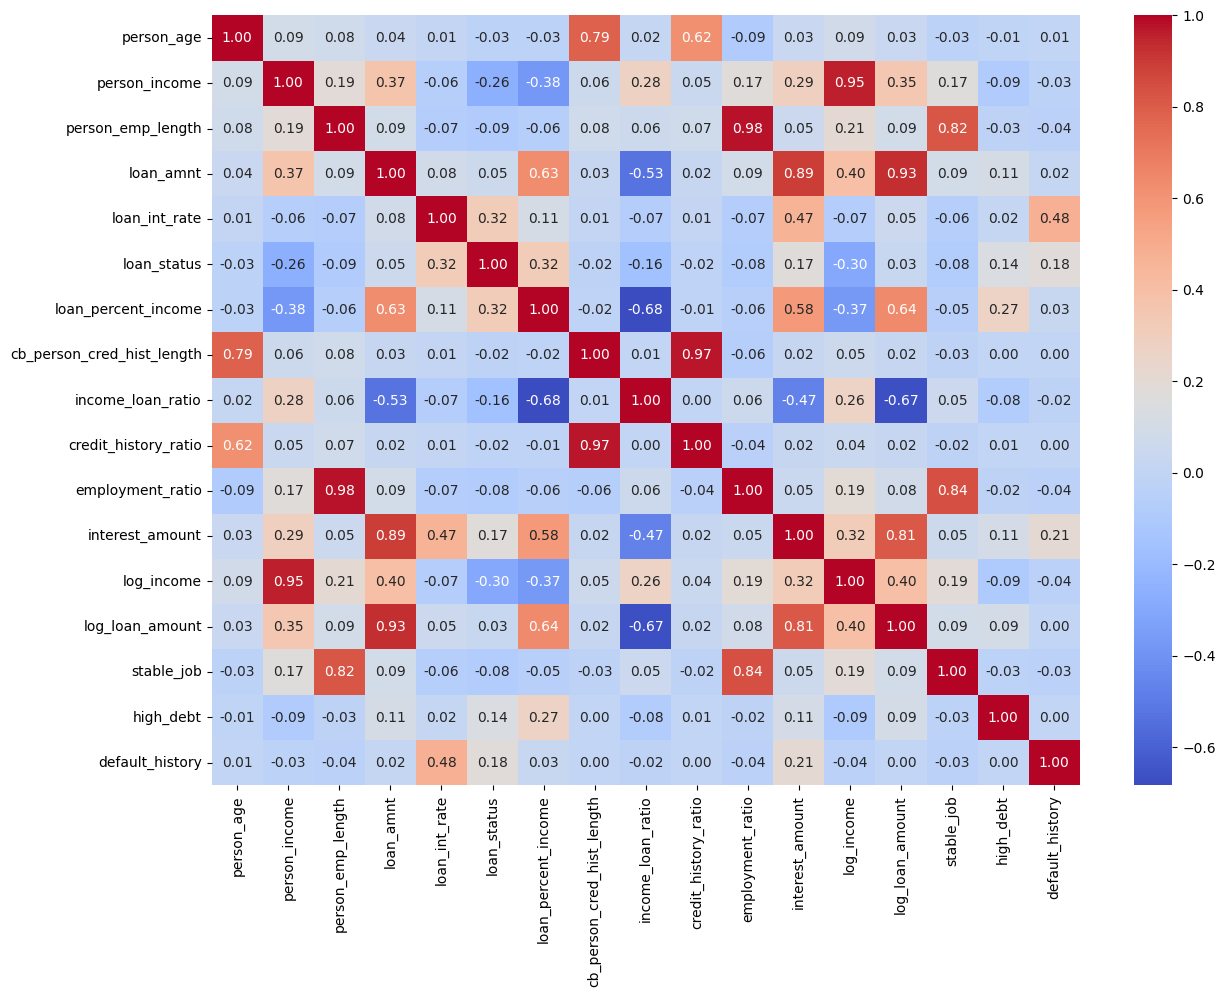

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(
    df_fe.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.show()

In [43]:
df_fe = df_fe.drop(columns=[
    'log_income',
    'log_loan_amount',
    'employment_ratio',
    'income_loan_ratio'
])

In [44]:
df_fe

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,credit_history_ratio,interest_amount,stable_job,high_debt,default_history,age_group,income_category
1,21,9600,OWN,5.00000,EDUCATION,B,1000,11.140000,0,0.10,N,2,0.095238,111.400000,1,0,0,18-25,Low
5,21,9900,OWN,2.00000,VENTURE,A,2500,7.140000,1,0.25,N,2,0.095238,178.500000,0,0,0,18-25,Low
9,21,10000,OWN,6.00000,VENTURE,D,1600,14.740000,1,0.16,N,3,0.142857,235.840000,1,0,0,18-25,Low
19,24,10800,MORTGAGE,8.00000,EDUCATION,B,1750,10.990000,1,0.16,N,2,0.083333,192.325000,1,0,0,18-25,Low
23,24,10980,OWN,0.00000,PERSONAL,A,1500,7.290000,0,0.14,N,3,0.125000,109.350000,0,0,0,18-25,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32256,38,59475,MORTGAGE,10.00000,MEDICAL,D,18125,14.840000,1,0.26,Y,13,0.342105,2689.750000,1,0,1,36-45,High
32258,38,67870,MORTGAGE,6.00000,MEDICAL,B,5000,11.017265,0,0.07,N,13,0.342105,550.863255,1,0,0,36-45,High
32269,37,21600,RENT,4.00000,MEDICAL,D,3800,11.017265,1,0.18,N,11,0.297297,418.656074,0,0,0,36-45,Low
32285,38,12000,OWN,4.79051,EDUCATION,A,4800,7.290000,1,0.40,N,12,0.315789,349.920000,0,1,0,36-45,Low


In [45]:
df_fe.select_dtypes(include=['object', 'category']).columns

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file', 'age_group', 'income_category'],
      dtype='object')

In [46]:
#encoding
grade_map = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
    'G': 7
}

df_fe['loan_grade'] = df_fe['loan_grade'].map(grade_map)

In [47]:
df_fe = df_fe.drop(columns=['cb_person_default_on_file'])

In [48]:
age_map = {
    '18-25': 1,
    '26-35': 2,
    '36-45': 3,
    '46-60': 4,
    '60+': 5
}

df_fe['age_group'] = df_fe['age_group'].map(age_map)

In [49]:
income_map = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Very High': 4
}

df_fe['income_category'] = df_fe['income_category'].map(income_map)

In [50]:
df_fe = pd.get_dummies(
    df_fe,
    columns=[
        'person_home_ownership',
        'loan_intent'
    ],
    drop_first=True
)

In [51]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26006 entries, 1 to 32293
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   person_age                   26006 non-null  int64   
 1   person_income                26006 non-null  int64   
 2   person_emp_length            26006 non-null  float64 
 3   loan_grade                   26006 non-null  int64   
 4   loan_amnt                    26006 non-null  int64   
 5   loan_int_rate                26006 non-null  float64 
 6   loan_status                  26006 non-null  int64   
 7   loan_percent_income          26006 non-null  float64 
 8   cb_person_cred_hist_length   26006 non-null  int64   
 9   credit_history_ratio         26006 non-null  float64 
 10  interest_amount              26006 non-null  float64 
 11  stable_job                   26006 non-null  int64   
 12  high_debt                    26006 non-null  int64   
 13  defaul

In [52]:
df_fe['age_group'] = df_fe['age_group'].cat.codes
df_fe['income_category'] = df_fe['income_category'].cat.codes

In [53]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26006 entries, 1 to 32293
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   26006 non-null  int64  
 1   person_income                26006 non-null  int64  
 2   person_emp_length            26006 non-null  float64
 3   loan_grade                   26006 non-null  int64  
 4   loan_amnt                    26006 non-null  int64  
 5   loan_int_rate                26006 non-null  float64
 6   loan_status                  26006 non-null  int64  
 7   loan_percent_income          26006 non-null  float64
 8   cb_person_cred_hist_length   26006 non-null  int64  
 9   credit_history_ratio         26006 non-null  float64
 10  interest_amount              26006 non-null  float64
 11  stable_job                   26006 non-null  int64  
 12  high_debt                    26006 non-null  int64  
 13  default_history      

In [54]:
bool_cols = df_fe.select_dtypes(include='bool').columns

df_fe[bool_cols] = df_fe[bool_cols].astype(int)

In [55]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26006 entries, 1 to 32293
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   26006 non-null  int64  
 1   person_income                26006 non-null  int64  
 2   person_emp_length            26006 non-null  float64
 3   loan_grade                   26006 non-null  int64  
 4   loan_amnt                    26006 non-null  int64  
 5   loan_int_rate                26006 non-null  float64
 6   loan_status                  26006 non-null  int64  
 7   loan_percent_income          26006 non-null  float64
 8   cb_person_cred_hist_length   26006 non-null  int64  
 9   credit_history_ratio         26006 non-null  float64
 10  interest_amount              26006 non-null  float64
 11  stable_job                   26006 non-null  int64  
 12  high_debt                    26006 non-null  int64  
 13  default_history      

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
#Define X and y
X = df_fe.drop('loan_status', axis=1)
y = df_fe['loan_status']



In [58]:
print(X.shape)
print(y.shape)

(26006, 23)
(26006,)


In [59]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [60]:
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train:",y_train.shape)
print("y_test",y_test.shape)

X_train: (20804, 23)
X_test: (5202, 23)
y_train: (20804,)
y_test (5202,)


In [61]:
print(y_train.value_counts())

loan_status
0    16579
1     4225
Name: count, dtype: int64


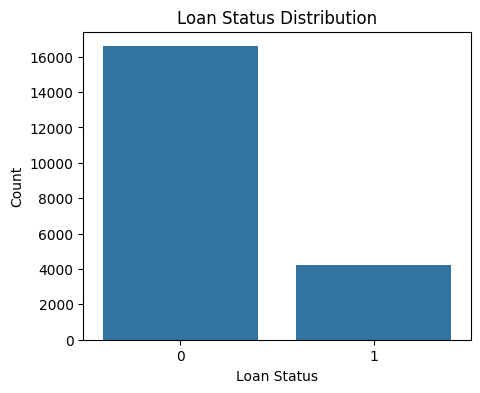

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.countplot(x=y_train)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

In [63]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [64]:
y_pred = model.predict(X_test)

In [65]:
from xgboost import XGBClassifier

In [66]:
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [67]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [68]:
y_pred = model.predict(X_test)

In [78]:
print(y_pred.sum())
print(y_pred[:10])

831
[0 0 0 0 0 0 0 0 0 0]


In [88]:
from sklearn.metrics import accuracy_score

train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 0.9622188040761392
Testing Accuracy : 0.9357939254133025


In [87]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      4145
           1       0.94      0.74      0.82      1057

    accuracy                           0.94      5202
   macro avg       0.94      0.86      0.89      5202
weighted avg       0.94      0.94      0.93      5202



In [81]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4091   54]
 [ 280  777]]


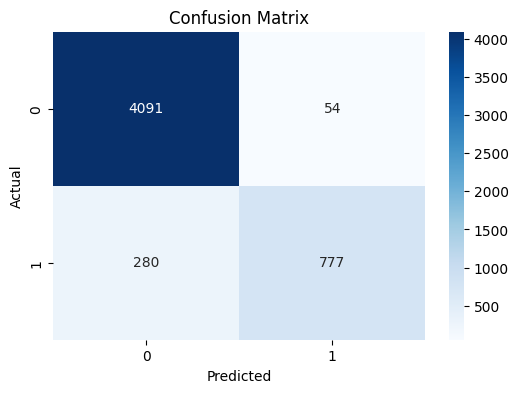

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

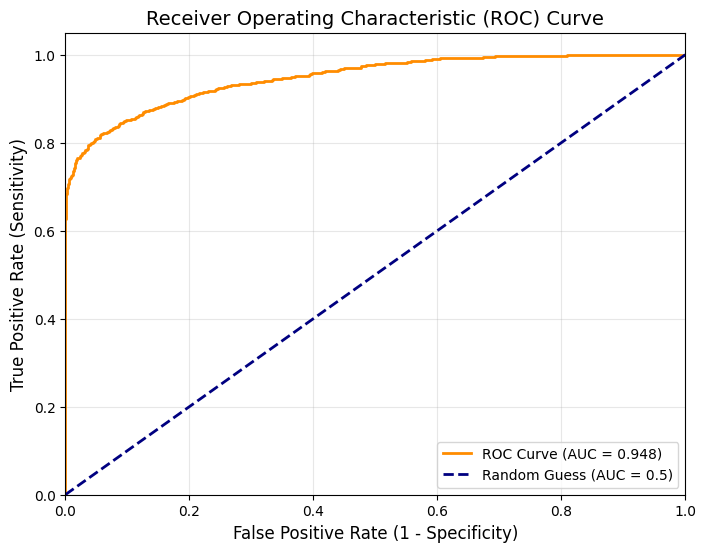

In [84]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Your existing code
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot it!
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

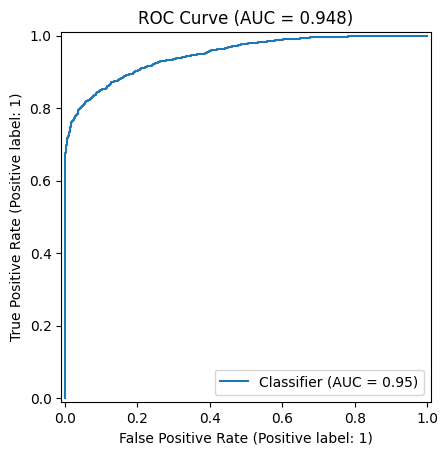

In [85]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title(f'ROC Curve (AUC = {roc_auc:.3f})')
plt.show()

<Figure size 1000x800 with 0 Axes>

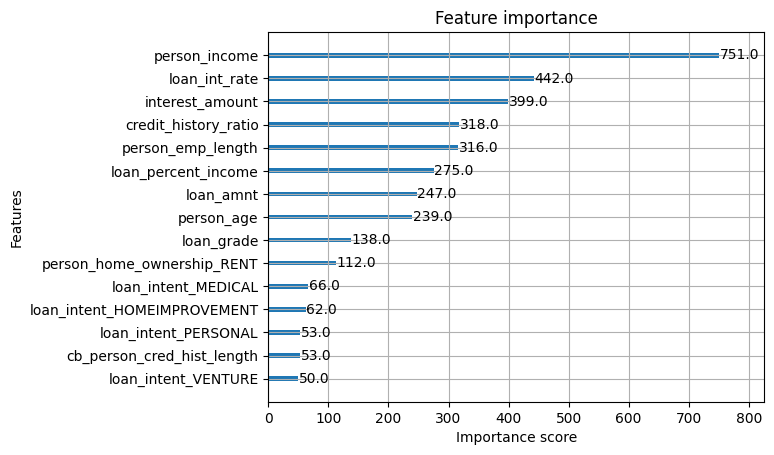

In [75]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(model, max_num_features=15)
plt.show()

In [90]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

In [89]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [91]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5]
}

In [92]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [93]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='accuracy', verbose=2)

In [94]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}


In [95]:
print(random_search.best_score_)

0.9318883104098497


In [96]:
best_model = random_search.best_estimator_

In [97]:
y_pred = best_model.predict(X_test)

In [98]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9367550941945406
